# Pre-RA Flow PM1: Cell type level subclustering

Creating frequency stat tables with cell type level and live frequencies/proportions

## Set Up

In [1]:
%config Completer.use_jedi = False
import scyan as sy
import os
import glob
import anndata
import re
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import scanpy.external as sce
import copy
from concurrent.futures import ProcessPoolExecutor


print(sy.__version__)
print(anndata.__version__)

/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


1.5.1
0.10.6


In [2]:
#### ==== parameter set up ==== ####
# define the working path
panel = "PM1"
# define l1 cell types to subset
cell_types = ["total_myeloid_cells"]
# define markers used for clustering
antigens = ["CD14","CD192 (CCR2)", "CD195 (CCR5)", "CD197 (CCR7)", "CD40", "CD86", "CD80","CD1c","CD370 (CLEC9A)","CD172a (SIRPa)","CD11b","CD11c","CD123","CD141","CD15","CD16","CD274 (PD-L1)","CD304" ,"CD33","CX3CR1"]
data_path='/home/jupyter/projects/pre-ra/flow/raw-data/' + panel + '/cache/'
fig_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/results/' + panel + '_celltype_subsample'  + "/"
proj_name = 'pre-ra_flow_clustering_' + panel
output_path = '/home/jupyter/projects/pre-ra/flow/02-clustering/data/' +panel + '/'

if not os.path.exists(fig_path): os.makedirs(fig_path)
    
if not os.path.exists(output_path): os.makedirs(output_path)

# define scanpy verbose levels
sc.settings.verbosity = 3
sc.settings.figdir = fig_path
sc.settings.n_jobs = 30

## Functions

In [3]:
def read_anndata_files(file_tuples):
    """
    Read Anndata objects from H5AD files and store them in a dictionary with custom names.

    Parameters:
        file_tuples (list of tuples): List of tuples where each tuple contains filename and desired name.

    Returns:
        dict: Dictionary containing Anndata objects with custom names.
    """
    anndata_dict = {}
    for filename, name in file_tuples:
        anndata_obj = anndata.read_h5ad(filename)
        anndata_dict[name] = anndata_obj
    return anndata_dict

In [4]:
def save_anndata_list(anndata_list, filenames):
    """
    Save a list of Anndata objects to separate H5AD files.

    Parameters:
        anndata_list (list): List of Anndata objects to be saved.
        filenames (list): List of filenames to save Anndata objects.

    Returns:
        None
    """
    # zip() combines two lists into a single tuple
    for anndata_obj, filename in zip(adata_downsampled_celltypes, filenames):
        print(adata_downsampled_celltypes[anndata_obj])
        adata_downsampled_celltypes[anndata_obj].write_h5ad(filename)

In [5]:
# make a function to find files
def get_filepaths_with_glob(root_path: str, file_regex: str):
    return glob.glob(os.path.join(root_path, file_regex))

In [6]:
#### parallelized leiden clustering
def run_leiden(adata, resolution, key_added):
    # Make a copy of adata for thread safety
    adata_copy = copy.deepcopy(adata)
    adata_clustering = sc.tl.leiden(adata_copy, resolution=resolution, key_added=key_added, copy=True)
    return adata_clustering.obs
 
def run_leiden_parallel(adata, tasks):
    with ProcessPoolExecutor(max_workers=5) as executor:
        # Make deep copies of adata for each task to ensure thread safety
        futures = [executor.submit(run_leiden, copy.deepcopy(adata), resolution, key_added) for resolution, key_added in tasks]
        
        results = [future.result() for future in futures]
 
    # Assign the results back to the original AnnData object
    for result, (_, key_added) in zip(results, tasks):
        adata.obs[key_added] = result[key_added]
 
    return adata

## Read in data

In [7]:
filenames = get_filepaths_with_glob(output_path, "adata_leiden*.h5ad")  
filenames

['/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_leiden_scaled_harmonized_umap_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad']

In [8]:
# Extract the cell types between "celltypes_" and "PT1.h5ad"
cell_types = [path.split('celltypes_')[1].split('_' +panel+'.h5ad')[0] for path in filenames]
cell_types

['total_myeloid_cells']

In [9]:
## turn filenames and cell types into tuple
file_tups = list(zip(filenames, cell_types))
file_tups

[('/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/adata_leiden_scaled_harmonized_umap_downsmpl_celltypes_total_myeloid_cells_PM1.h5ad',
  'total_myeloid_cells')]

In [10]:
adata_downsampled_celltypes = read_anndata_files(file_tups)
adata_downsampled_celltypes

{'total_myeloid_cells': AnnData object with n_obs × n_vars = 4192099 × 25
     obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023', 'leiden_res_2', 'leiden_res_2.5', 'leiden_res_3', 'leiden_res_1.0'
     var: 'antigens', 'gating_antigens', 'highly_variable'
     uns: 'neighbors', 'pca', 'scyan_scaling_means', 'scyan_scaling_stds'
     obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
     varm: 'PCs'
     obsp: 'connectivities', 'distances'}

In [11]:
get_filepaths_with_glob(data_path,"**/*PB04671-00*")

['/home/jupyter/projects/pre-ra/flow/raw-data/PM1/cache/6c86f794-3cf8-45cb-b2f0-64486e65f90c/Flow_Cyanno_PM1_PB04671-00_summary_frequency_stats.csv',
 '/home/jupyter/projects/pre-ra/flow/raw-data/PM1/cache/cb72766c-cc89-4211-a940-89e5e2fa9d47/Flow_Cyanno_PM1_PB04671-00_summary_frequency_stats.csv']

In [12]:
## read in freq df
counts_path = get_filepaths_with_glob(output_path, "counts*")  
print(counts_path)

counts_df = pd.read_csv(counts_path[0])
counts_df.tail()

['/home/jupyter/projects/pre-ra/flow/02-clustering/data/PM1/counts_freq_celltypes_sample_select_PM1.csv']


,Unnamed: 0,sample_id,sample_select_b_cells,sample_select_debris,sample_select_t_cells,sample_select_total_myeloid_cells,sample_select_total_nk_cells,sample_select_unknown,sample_select_All,downsample_total_myeloid_cells,downsample_All
124,124,PB04671-00,48928,4490,197980,73278,44334,141736,510746,40000,40000
125,125,PB04906-00,67206,7234,206888,32714,62264,171430,547736,32714,32714
126,126,PB04933-00,64514,18266,156946,46208,17110,84654,387698,40000,40000
127,127,PB04937-00,42130,11582,245886,20296,117280,163536,600710,20296,20296
128,128,All,3525529,728132,18104954,6811149,4544043,12523177,46236984,4192099,4192099


In [13]:
counts_df.describe

<bound method NDFrame.describe of      Unnamed: 0   sample_id  sample_select_b_cells  sample_select_debris  \
0             0  PB00052-02                  16974                  3233   
1             1  PB00055-02                  42577                  5958   
2             2  PB00056-02                  31663                  5508   
3             3  PB00057-02                  21286                  1902   
4             4  PB00058-03                   8676                  1645   
..          ...         ...                    ...                   ...   
124         124  PB04671-00                  48928                  4490   
125         125  PB04906-00                  67206                  7234   
126         126  PB04933-00                  64514                 18266   
127         127  PB04937-00                  42130                 11582   
128         128         All                3525529                728132   

     sample_select_t_cells  sample_select_total_myelo

In [14]:
len(counts_df['sample_id'].unique())

129

In [15]:
counts_df = counts_df[counts_df['sample_id'] != "All"]
sample_unique = counts_df['sample_id'].tolist()
print(counts_df)
sample_unique[:5]

     Unnamed: 0   sample_id  sample_select_b_cells  sample_select_debris  \
0             0  PB00052-02                  16974                  3233   
1             1  PB00055-02                  42577                  5958   
2             2  PB00056-02                  31663                  5508   
3             3  PB00057-02                  21286                  1902   
4             4  PB00058-03                   8676                  1645   
..          ...         ...                    ...                   ...   
123         123  PB04652-00                  34636                  6253   
124         124  PB04671-00                  48928                  4490   
125         125  PB04906-00                  67206                  7234   
126         126  PB04933-00                  64514                 18266   
127         127  PB04937-00                  42130                 11582   

     sample_select_t_cells  sample_select_total_myeloid_cells  \
0                    9

['PB00052-02', 'PB00055-02', 'PB00056-02', 'PB00057-02', 'PB00058-03']

## Calculate proportions

Since total live freq and cell type freq is already labeled in counts_freq_celltypes_sample_select*.csv,
use these sum as denominator

In [20]:
#### check leiden cluster

leiden_res = {'total_myeloid_cells': 'leiden_res_1.0'}
label = 'total_myeloid_cells'
sub_adata = adata_downsampled_celltypes[label]
print("Key:", label)
print("Value:", sub_adata)
print("Leiden: " , leiden_res[label]) 
freq_counts = sy.tools.cell_type_ratios(sub_adata, groupby=['sample_id','l1_labels'],normalize=False, key=leiden_res[label], among=None)

print(freq_counts.head())


Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023', 'leiden_res_2', 'leiden_res_2.5', 'leiden_res_3', 'leiden_res_1.0'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'neighbors', 'pca', 'scyan_scaling_means', 'scyan_scaling_stds'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
Leiden:  leiden_res_1.0


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/tools/biomarkers.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(groupby)


                                0 count  1 count  2 count  3 count  4 count  \
sample_id  l1_labels                                                          
PB00052-02 total_myeloid_cells      453     1082      439     1012      217   
PB00055-02 total_myeloid_cells     1487     1394     2606     5093      709   
PB00056-02 total_myeloid_cells     7349     5857     4233     7816     1939   
PB00057-02 total_myeloid_cells     4498     4775     2706     4330     2607   
PB00058-03 total_myeloid_cells     9062     4839     6879    10082     2969   

                                5 count  6 count  7 count  8 count  9 count  \
sample_id  l1_labels                                                          
PB00052-02 total_myeloid_cells     1567     1754      944      989      212   
PB00055-02 total_myeloid_cells     4768     1004      841     1297      234   
PB00056-02 total_myeloid_cells     2230     5431     2648     1283      378   
PB00057-02 total_myeloid_cells     2418      804   

In [63]:
%%time

## define leiden res of interest

leiden_res = {'total_myeloid_cells': 'leiden_res_1.0'}

for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    freq_counts = sy.tools.cell_type_ratios(sub_adata, groupby=['sample_id','l1_labels'],normalize=False, key=leiden_res[label], among=None)
    freq_prop = sy.tools.cell_type_ratios(sub_adata, groupby=['sample_id','l1_labels'],normalize=True, key=leiden_res[label], among=None)
    
    # longwise format
    freq_count_melt = freq_counts.melt(ignore_index=False, value_name="counts", var_name='cluster' ).reset_index()

    #remove 'ratio' suffix in leiden column
    freq_count_melt["cluster"] = freq_count_melt["cluster"].str.replace(' count','', regex = True)

    freq_count_melt["cluster"] = "c" +freq_count_melt["cluster"]

    freq_count_melt = freq_count_melt.merge(counts_df[['sample_id', 'downsample_' + label]],how= 'inner')

    freq_count_melt
    
    freq_prop_melt = freq_prop.melt(ignore_index=False, value_name="frequency", var_name='cluster').reset_index()

    #remove 'ratio' suffix in leiden column
    freq_prop_melt['cluster'] = freq_prop_melt['cluster'].str.replace(' ratio','', regex = True)

    freq_prop_melt['cluster'] = "c" +freq_prop_melt['cluster']

    freq_prop_melt
    
    counts = freq_count_melt.merge(freq_prop_melt[['sample_id','cluster', 'frequency']], how = 'inner', on = ['sample_id','cluster'])

    counts['leiden_res'] = leiden_res[label]
    
    counts.to_csv(output_path + "cell_frequency_table_downsmpl_sample_select_" + label + "_" +  leiden_res[label] +"_"  +panel + ".csv",index=False)
    
    

Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023', 'leiden_res_2', 'leiden_res_2.5', 'leiden_res_3', 'leiden_res_1.0'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'neighbors', 'pca', 'scyan_scaling_means', 'scyan_scaling_stds'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/tools/biomarkers.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(groupby)
/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/tools/biomarkers.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(groupby)


CPU times: user 791 ms, sys: 0 ns, total: 791 ms
Wall time: 859 ms


## Expression plots

In [11]:
fig_path = fig_path + panel + "_leiden/"

if not os.path.exists(fig_path): os.makedirs(fig_path)
sc.settings.figdir = fig_path
leiden_res = {'total_myeloid_cells': 'leiden_res_1.0'}


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


    using data matrix X directly


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


Storing dendrogram info using `.uns['dendrogram_leiden_res_1.0']`


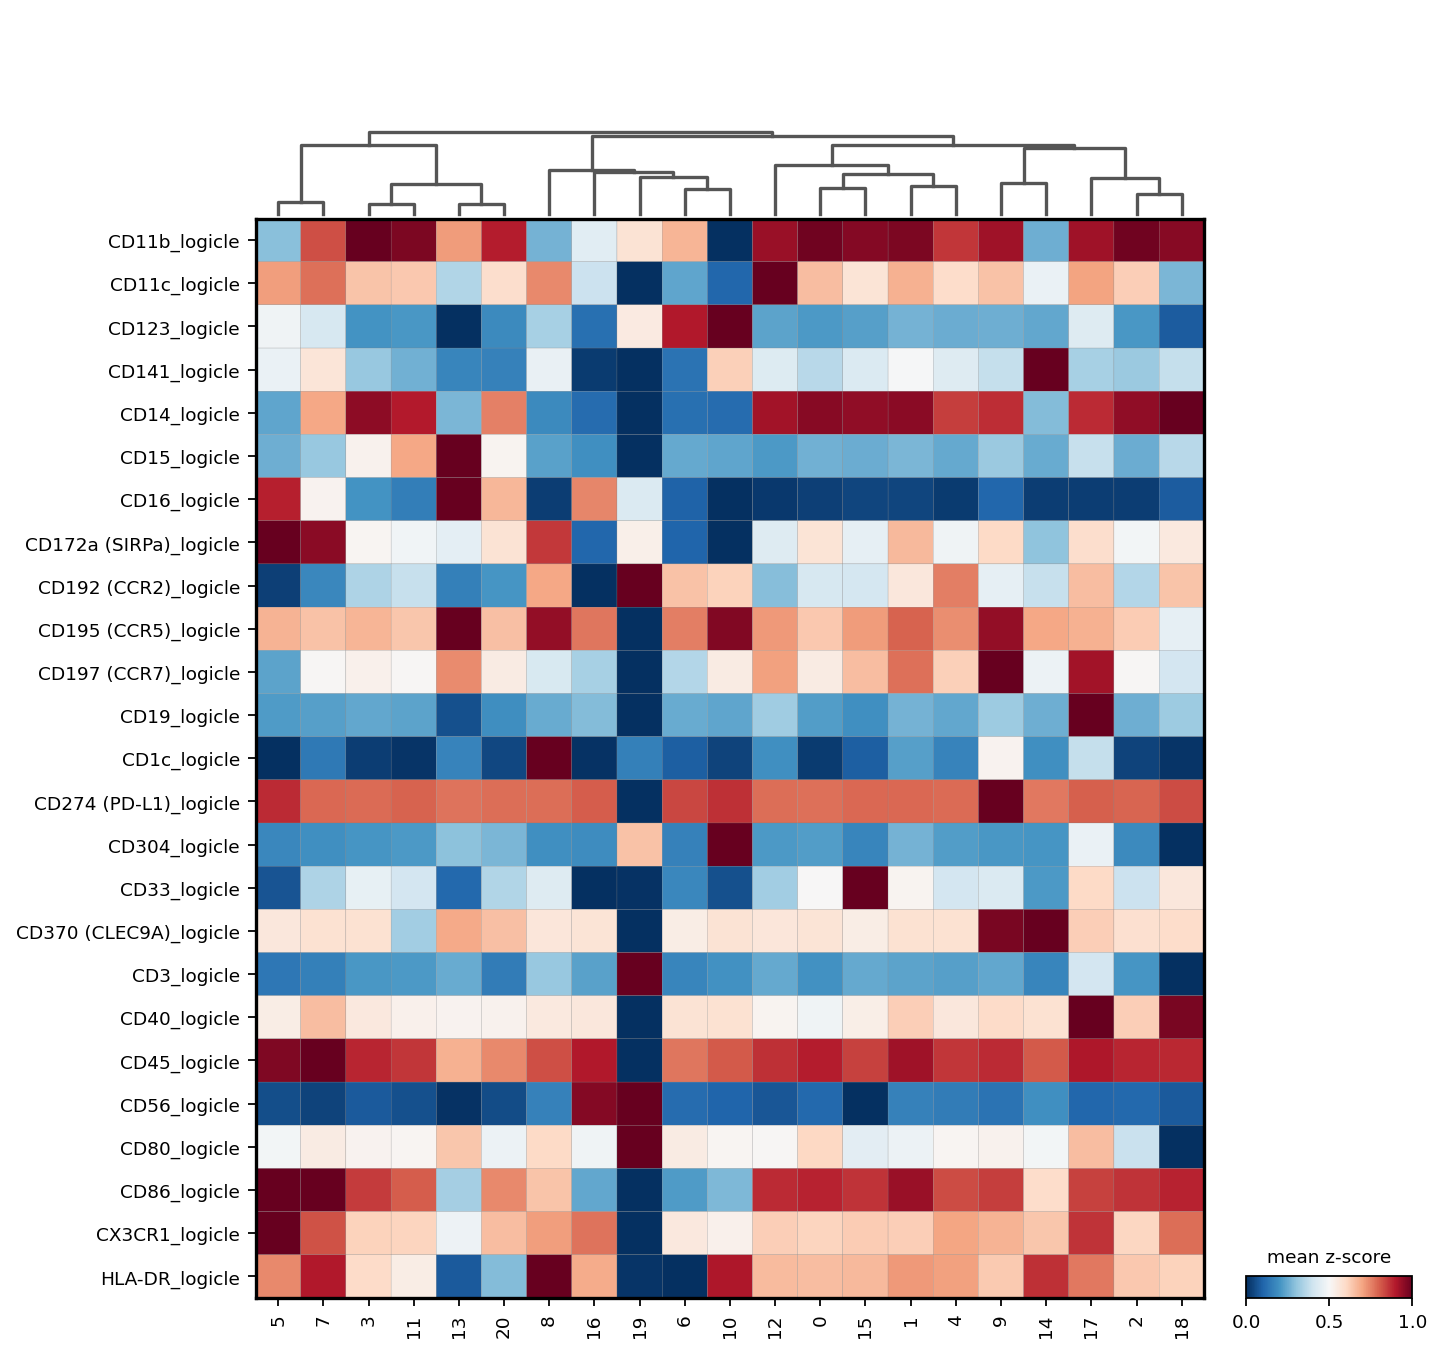

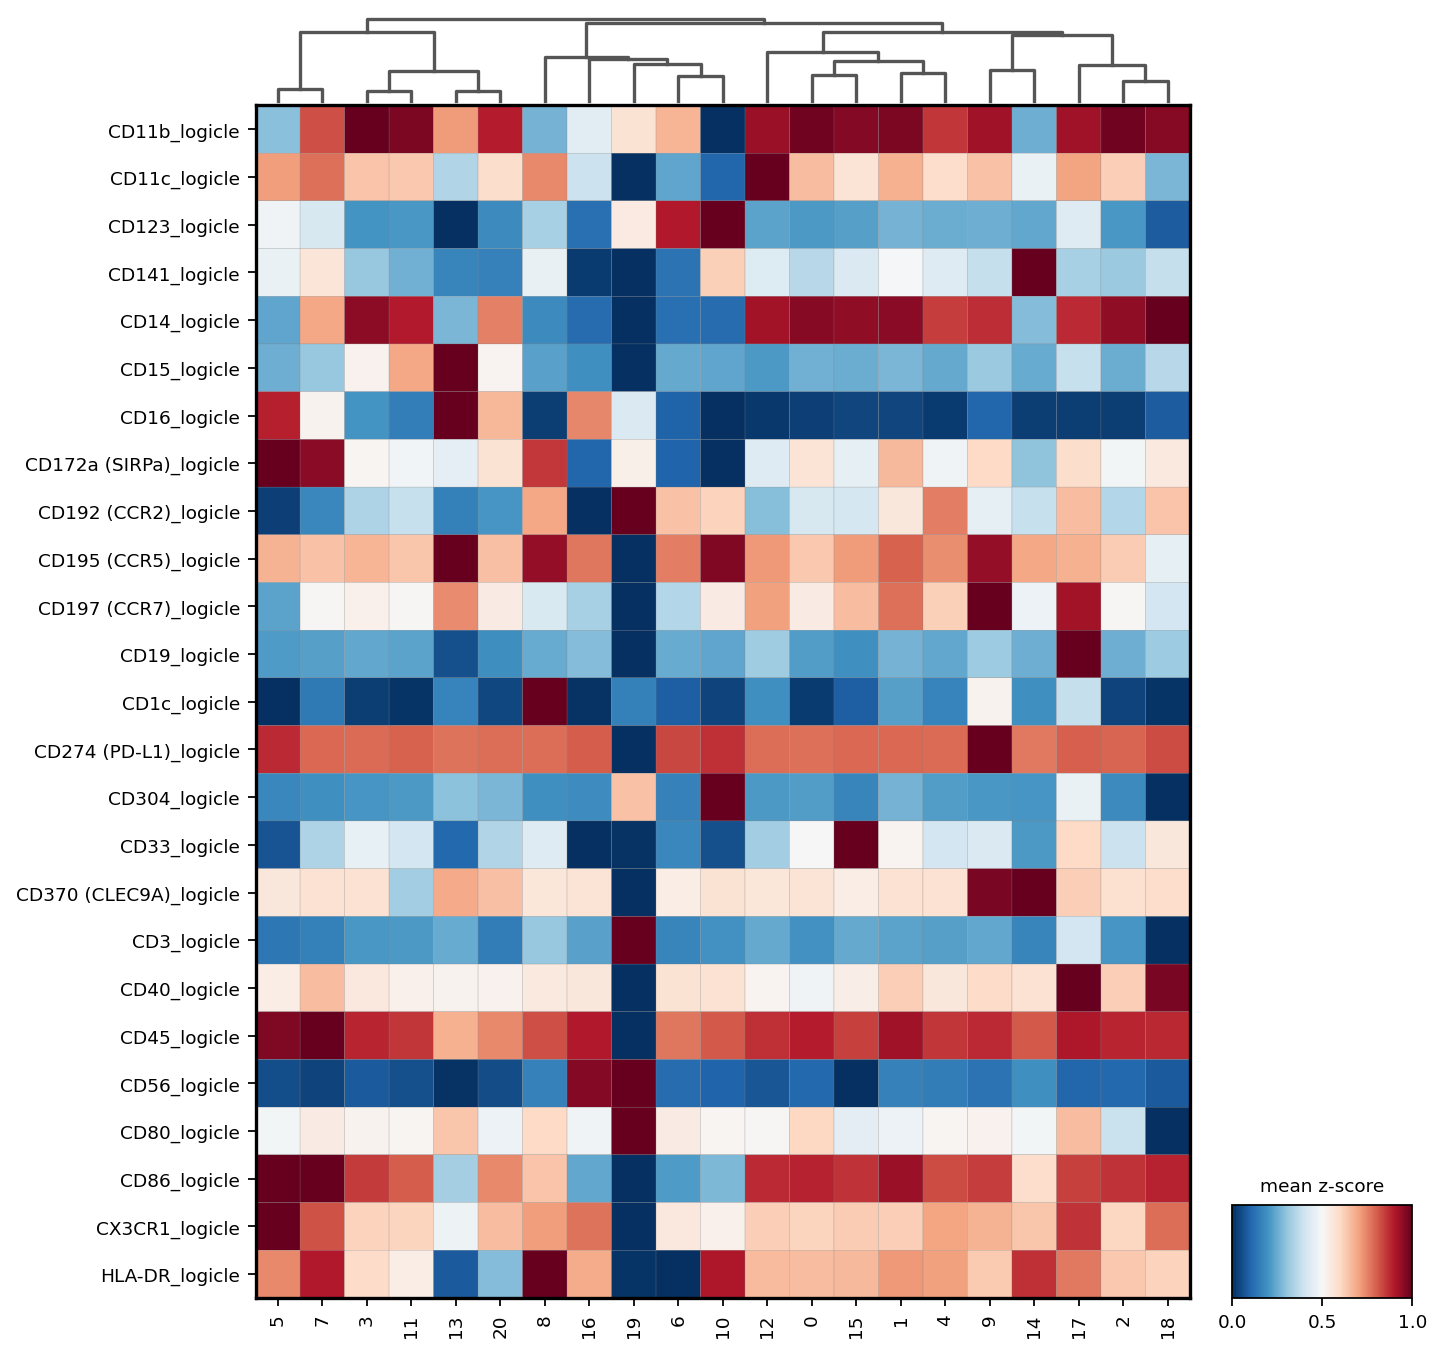

In [12]:
### add marker level rescaling to grouped mean heatmap

for label, sub_adata in adata_downsampled_celltypes.items():
    p1 = sc.pl.matrixplot(sub_adata, sub_adata.var_names.sort_values(), leiden_res[label],standard_scale='var', dendrogram=True,colorbar_title='mean z-score', cmap='RdBu_r', swap_axes=True, return_fig=True, show=True)

    p1.show()
    p1.savefig(fig_path  + label   + "_avg_mean_heatmap_marker_rescale_" + leiden_res[label] + "_" +panel + ".png",  dpi=400, bbox_inches='tight')


Key: total_myeloid_cells
Value: AnnData object with n_obs × n_vars = 4192099 × 25
    obs: 'Unnamed: 0', 'sample_id', 'cell_id', 'barcode', 'Time', 'SSC-W', 'SSC-H', 'SSC-A', 'FSC-W', 'FSC-H', 'FSC-A', 'SSC-B-W', 'SSC-B-H', 'SSC-B-A', 'Viability_logicle', 'labels', 'batch', 'panel', 'l1_labels', 'sample.sampleKitGuid', 'Status_Xsec', 'Status_Long', 'subject.biologicalSex', 'subject.subjectGuid', 'days_to_conversion', 'age_conv', 'bmi_conv', 'Age2023', 'leiden_res_2', 'leiden_res_2.5', 'leiden_res_3', 'leiden_res_1.0'
    var: 'antigens', 'gating_antigens', 'highly_variable'
    uns: 'neighbors', 'pca', 'scyan_scaling_means', 'scyan_scaling_stds'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()


    using data matrix X directly


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/tools/_dendrogram.py:133: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = rep_df.groupby(level=0).mean()


Storing dendrogram info using `.uns['dendrogram_leiden_res_1.0']`


/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


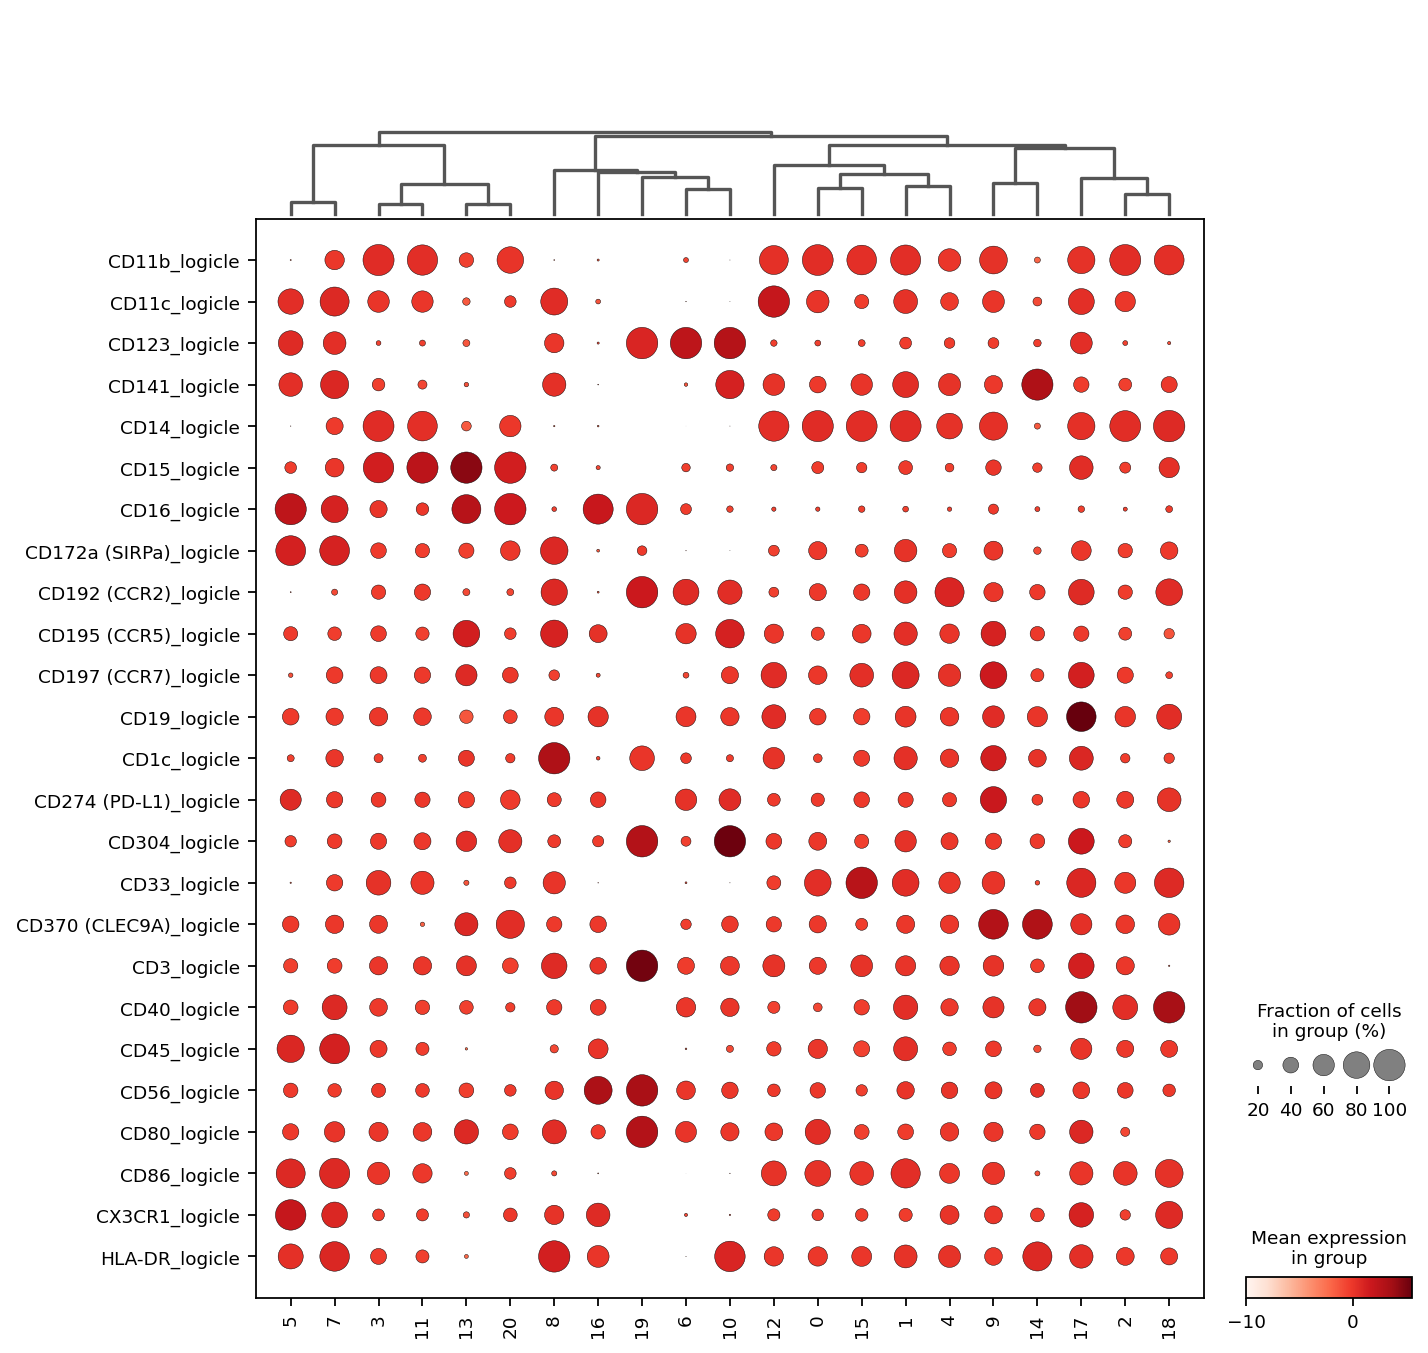

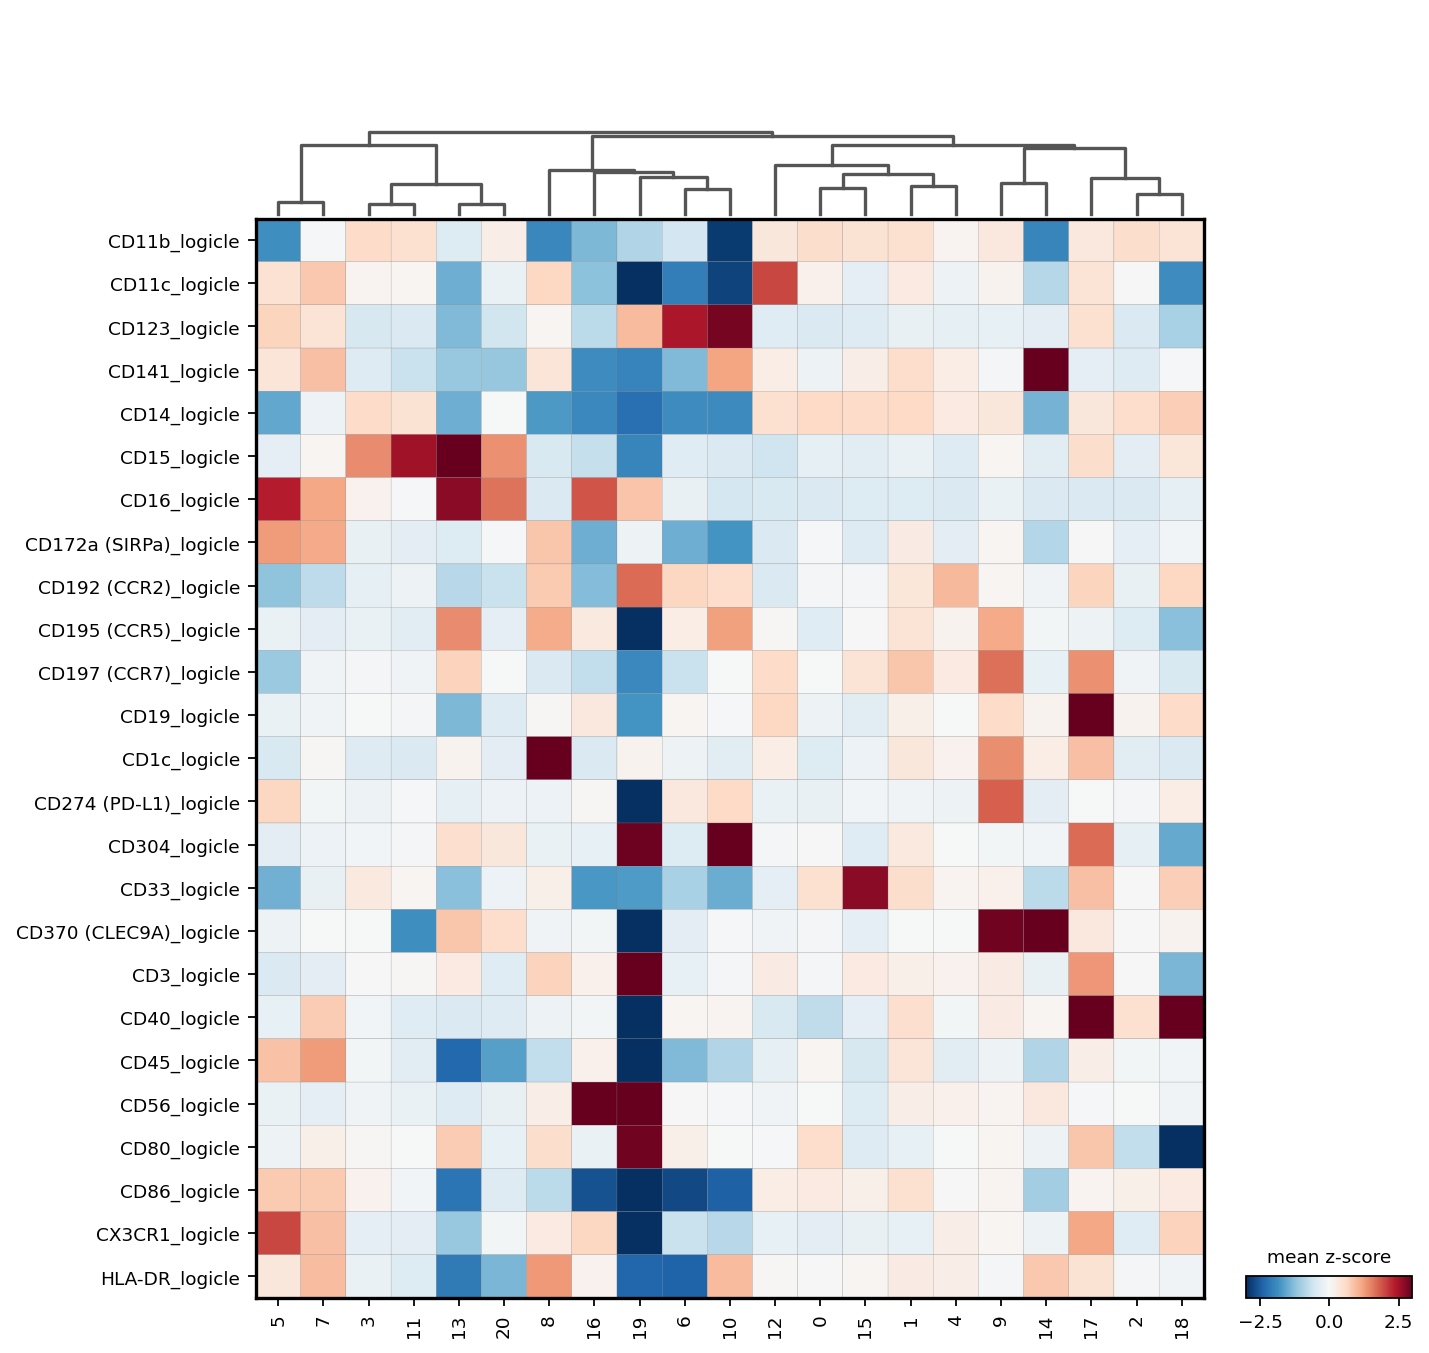

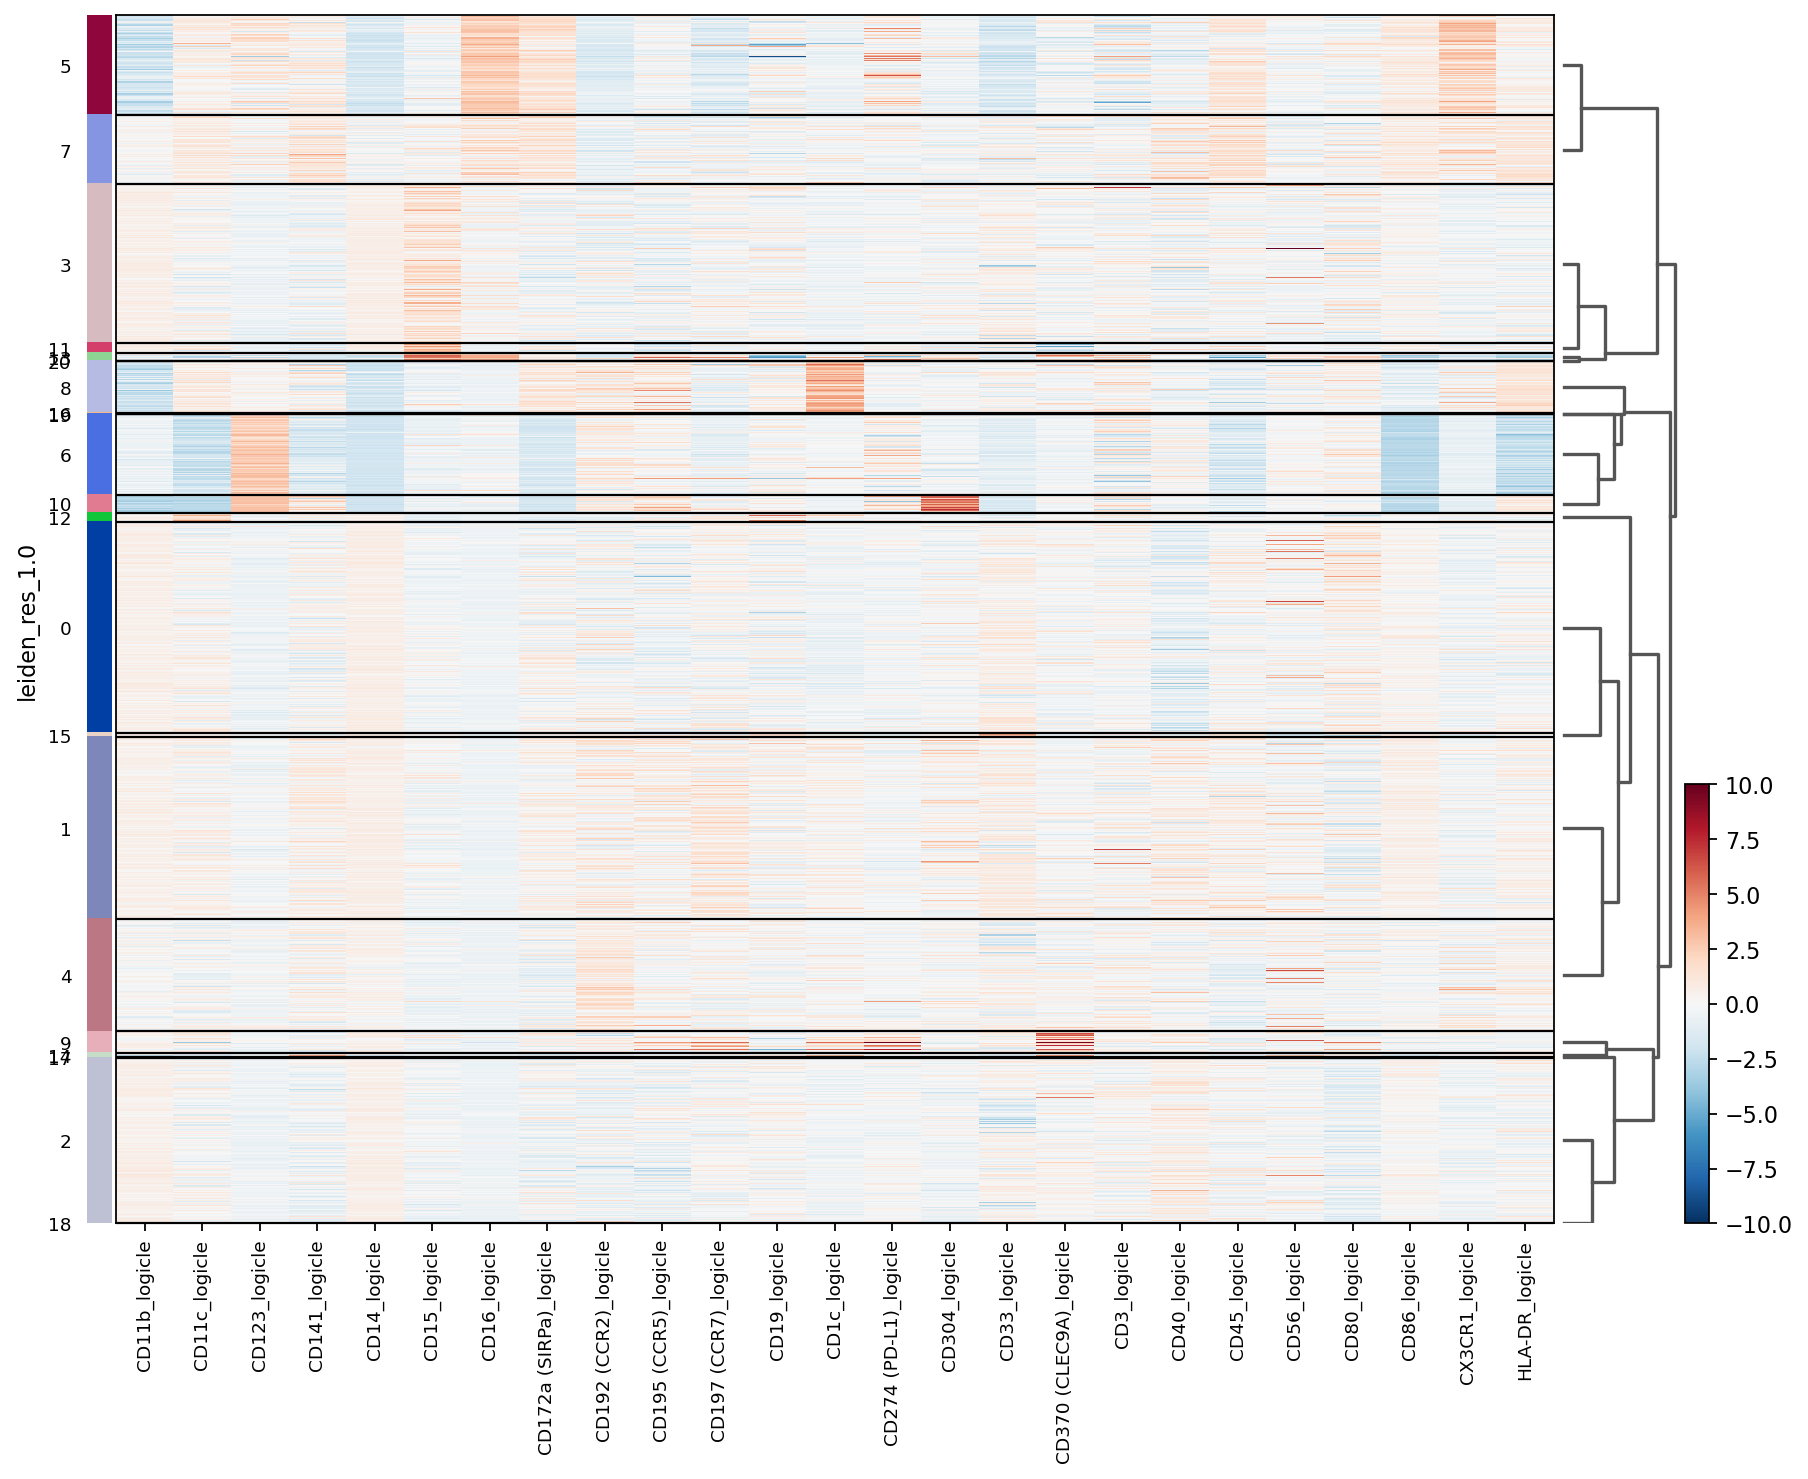

/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be chan

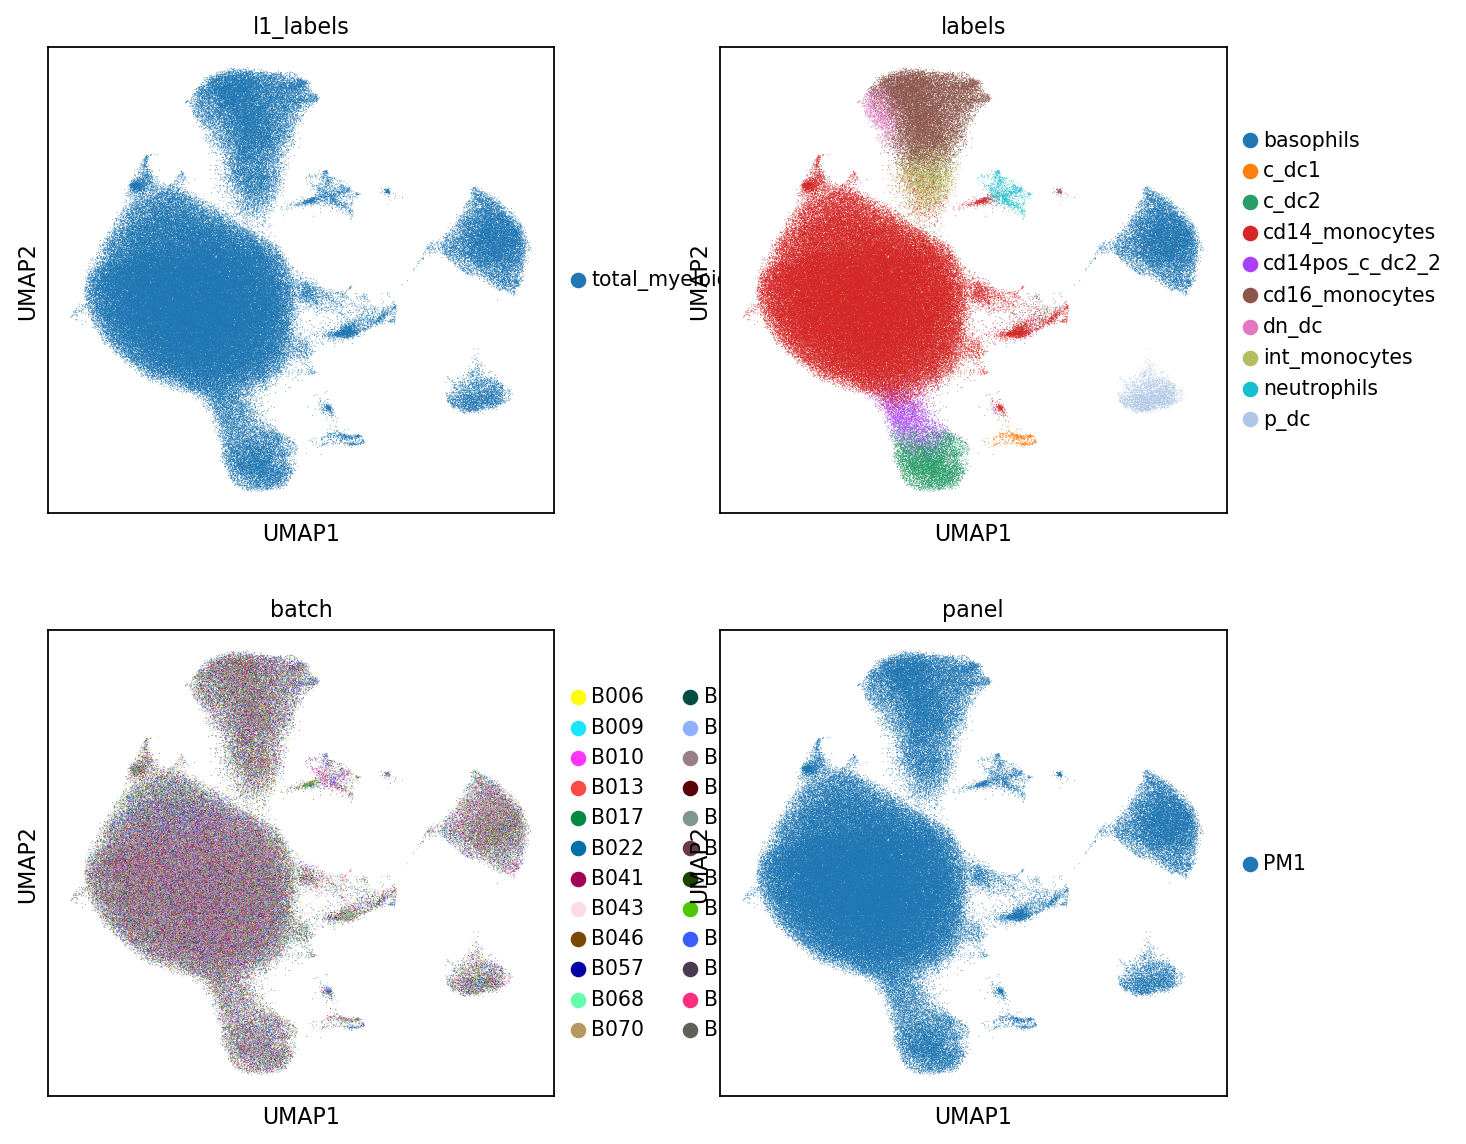

/home/jupyter/envs/libs/scyan/lib/python3.9/site-packages/scyan/plot/_scanpy_plot/umap.py:885: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


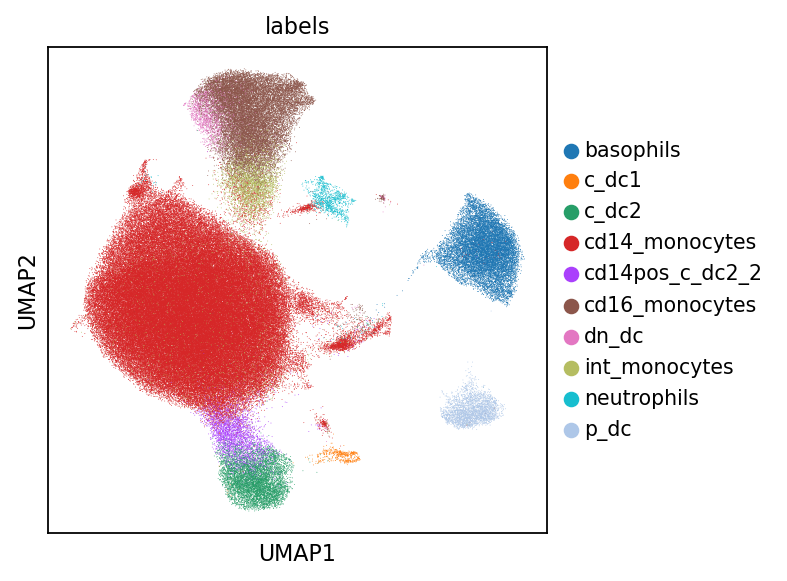

In [68]:
for label, sub_adata in adata_downsampled_celltypes.items():
    print("Key:", label)
    print("Value:", sub_adata)
    
    
    p1 = sc.pl.dotplot(sub_adata, sub_adata.var_names.sort_values(), leiden_res[label], dendrogram=True, swap_axes=True,return_fig=True, show=True)
    p1.savefig(fig_path  + label   + "_dotplot_exp_" + leiden_res[label] + "_" +panel + ".png",  dpi=400, bbox_inches='tight')

    p1 = sc.pl.matrixplot(sub_adata, sub_adata.var_names.sort_values(), leiden_res[label], dendrogram=True,colorbar_title='mean z-score', cmap='RdBu_r', swap_axes=True, vmin=-3, vmax=3, return_fig=True, show=True)
    p1.savefig(fig_path  + label   + "_avg_mean_heatmap_" + leiden_res[label] + "_" +panel + ".png",  dpi=400, bbox_inches='tight')

    sc.pl.heatmap(sub_adata, sub_adata.var_names.sort_values(), groupby=leiden_res[label], cmap='RdBu_r', dendrogram=True,show=True,figsize=(13,10), save= "_"+label   +"_cell_lvl_heatmap_" + leiden_res[label] + "_" +panel + ".png")

    p1=sy.plot.umap(sub_adata, color=['l1_labels','labels', 'batch','panel'], ncols =2, return_fig = True)
    p1.savefig(fig_path + label + "_umap_labels_batch_panel_"+ leiden_res[label] + "_" +panel + ".png",dpi=400, bbox_inches='tight')

    p1=sy.plot.umap(sub_adata, color=['labels'], return_fig = True)
    p1.savefig(fig_path + label + "_umap_l1_labels_"+ leiden_res[label] + "_" +panel + ".png",dpi=400, bbox_inches='tight')


    p1 = sy.plot.umap(sub_adata, color= ['leiden_res_2', 'leiden_res_2.5', 'leiden_res_3', 'leiden_res_1.0'] ,return_fig = True, size = .5, ncols = 3)
    p1.savefig(leiden_fig_path + label   + "_umap_leiden_resolutions_" + panel + ".png",  dpi=400, bbox_inches='tight')
    
    
    